# Chapter 1 — Overview of Big Data

**Course 888102 — International College of Digital Innovation, Chiang Mai University**

> *Big data is not just "a lot of data" — it is data at a scale where the tools themselves have to change.*

This notebook is the Chapter 1 lecture, turned into something you can run, change, and break. Every figure
from the slides is reproduced here from real code, every number is computed rather than quoted, and the
lecture's two worked examples are extended so you can see what happens when the inputs change.

### Learning objectives

By the end of this chapter you should be able to:

1. **Understand the impacts** — explain why big data matters and point to places where it already shapes
   everyday decisions.
2. **Differentiate the terms** — tell apart *big data*, *data analytics*, and *data science*, and say which
   one is a material, which is an activity, and which is a discipline.
3. **Know the skills** — identify the skills and job roles that big-data work requires, and match a task to
   the role that owns it.

### How this notebook is organized

| Section | What it covers |
|---|---|
| 1 | Data vs. big data, and the DIKW pyramid |
| 2 | The scale of data: bytes → yottabytes, decimal vs. binary units, the 97 ZB worked example |
| 3 | The three primary sources of big data |
| 4 | How fast data is growing — growth rates, doubling time, projection |
| 5 | Applications: Starbucks, Netflix/Amazon recommenders, COVID dashboards |
| 6 | Necessary skills — the Data Science Venn diagram |
| 7 | The three big-data roles compared |
| 8 | Big data vs. data analytics vs. data science, and the analytics maturity ladder |
| 9–11 | Glossary, self-check quiz, summary |
| 12 | Graded homework 📝 |

Work top to bottom, and **run every code cell as you reach it** — later cells depend on earlier ones.

In [1]:
# Run this cell first — everything below depends on it.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# A fixed seed means every student in the class gets exactly the same "random" numbers,
# so your answers can be compared against your classmates' and against the solution key.
rng = np.random.default_rng(888102)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.5 | numpy 2.4.6


---
## 1. What is data? What is big data?

**Data** is a collection of facts in a raw or unorganized form — numbers, characters, images, opinions,
distances, temperatures, scores — collected by observation or experimentation. On its own, a single fact
usually means nothing. `37.8` is not information until you know it is a body temperature, measured in degrees
Celsius, this morning, from a particular patient.

**Big data** is a massive amount of data sets that **cannot be stored, processed, or analyzed using
traditional tools** — a single spreadsheet or a single laptop database no longer works.

Read that definition carefully, because it is *relative*, not absolute:

- It says nothing about a fixed number of gigabytes. A 5 GB file is "big data" for a program that must hold
  it all in a phone's memory, and utterly ordinary for a cloud data warehouse.
- The test is **"do my normal tools still work?"** The moment the answer is no — the spreadsheet refuses to
  open, the query takes three days, the file will not fit on one disk — you have crossed into big data and
  you need a different class of tool.

That is why this course spends its time on tools and methods rather than on a threshold number.

### 1.1 From data to wisdom — the DIKW pyramid

Data is the bottom of a ladder, not the top. The **DIKW pyramid** (Data → Information → Knowledge → Wisdom)
is the classic way to describe how raw facts become decisions:

| Level | What it is | Question it answers | Example |
|---|---|---|---|
| **Data** | Raw, unprocessed facts | — | `37.8`, `38.1`, `39.0` |
| **Information** | Data given context and structure | *What?* | "Patient A's temperature over three days: 37.8, 38.1, 39.0 °C" |
| **Knowledge** | Patterns and relationships found in information | *How?* | "The fever is rising ~0.6 °C per day, which usually indicates an untreated infection" |
| **Wisdom** | Judgment about what *should* be done | *Why / what now?* | "Start antibiotics today rather than waiting for the culture result" |

Everything in this course lives on the bottom three rungs. The top rung — deciding what to actually *do* — is
still a human responsibility, and the whole point of getting the bottom three right is to make that human
decision better informed.

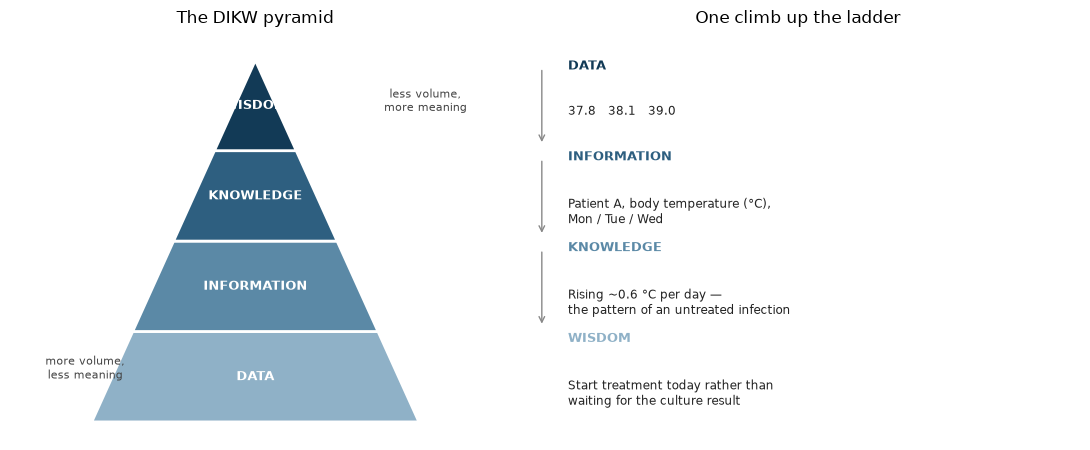

In [2]:
# Draw the DIKW pyramid, and show a worked climb up it with the fever example.
fig, (ax_pyr, ax_ex) = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [1, 1.15]})

levels = ["DATA", "INFORMATION", "KNOWLEDGE", "WISDOM"]
colors = ["#8FB1C7", "#5B89A6", "#2E5F80", "#123A56"]
n = len(levels)

# Each level is a horizontal slice of a triangle: wide at the bottom, narrow at the top.
for i, (label, color) in enumerate(zip(levels, colors)):
    y0, y1 = i / n, (i + 1) / n
    half_bottom, half_top = (1 - y0) / 2, (1 - y1) / 2
    ax_pyr.fill([-half_bottom, half_bottom, half_top, -half_top],
                [y0, y0, y1, y1], color=color, edgecolor="white", linewidth=2)
    ax_pyr.text(0, (y0 + y1) / 2, label, ha="center", va="center",
                color="white", fontweight="bold", fontsize=9.5)

ax_pyr.annotate("more volume,\nless meaning", xy=(-0.52, 0.12), fontsize=8, ha="center", color="#444")
ax_pyr.annotate("less volume,\nmore meaning", xy=(0.52, 0.86), fontsize=8, ha="center", color="#444")
ax_pyr.set_xlim(-0.75, 0.75)
ax_pyr.set_ylim(-0.05, 1.08)
ax_pyr.axis("off")
ax_pyr.set_title("The DIKW pyramid")

# The same four rungs, climbed with one concrete example.
steps = [
    ("DATA", "37.8   38.1   39.0"),
    ("INFORMATION", "Patient A, body temperature (°C),\nMon / Tue / Wed"),
    ("KNOWLEDGE", "Rising ~0.6 °C per day —\nthe pattern of an untreated infection"),
    ("WISDOM", "Start treatment today rather than\nwaiting for the culture result"),
]
for i, (level, text) in enumerate(steps):
    y = 3 - i
    ax_ex.text(0.02, y + 0.28, level, fontsize=9, fontweight="bold", color=colors[3 - i])
    ax_ex.text(0.02, y - 0.12, text, fontsize=8.5, va="top", color="#222")
    if i < len(steps) - 1:
        ax_ex.annotate("", xy=(-0.03, y - 0.55), xytext=(-0.03, y + 0.3),
                       arrowprops=dict(arrowstyle="->", color="#888"))
ax_ex.set_xlim(-0.08, 1)
ax_ex.set_ylim(-0.8, 3.7)
ax_ex.axis("off")
ax_ex.set_title("One climb up the ladder")

plt.show()

**How to read it:** the pyramid narrows as you go up because *meaning* is a filter. Millions of temperature
readings (wide base) collapse into one clinical decision (narrow tip). A common beginner mistake is to think
more data automatically produces better decisions — it only does so if each step up the ladder is done well.
Bad information built from excellent data is still bad information.

### 1.2 Why traditional tools break

"Traditional tools stop working" sounds abstract until you watch it happen. The cell below scans a table row
by row — the way a beginner's `for` loop would — and times it at several sizes, then estimates how long the
same approach would take on a billion rows.

In [3]:
# How long does a simple row-by-row scan take as the table grows?
import time

sizes = [10_000, 100_000, 1_000_000]
timings = []

for n_rows in sizes:
    values = rng.integers(0, 100, size=n_rows)
    start = time.perf_counter()
    total = 0
    for v in values:            # the "one row at a time" approach
        total += v
    timings.append(time.perf_counter() - start)

scan = pd.DataFrame({
    "Rows": sizes,
    "Seconds": [round(t, 4) for t in timings],
    "Rows per second": [f"{n / t:,.0f}" for n, t in zip(sizes, timings)],
})
print(scan.to_string(index=False))

# Extrapolate the largest measured rate to a billion rows, and to a trillion.
rate = sizes[-1] / timings[-1]
for n_rows, label in [(1e9, "1 billion rows"), (1e12, "1 trillion rows")]:
    seconds = n_rows / rate
    print(f"\n{label}: about {seconds:,.0f} s  =  {seconds/3600:,.1f} hours  =  {seconds/86400:,.2f} days")

   Rows  Seconds Rows per second
  10000   0.0006      18,004,393
 100000   0.0058      17,330,695
1000000   0.0570      17,539,664

1 billion rows: about 57 s  =  0.0 hours  =  0.00 days

1 trillion rows: about 57,014 s  =  15.8 hours  =  0.66 days


**How to read it:** the scan rate is roughly constant, so the time grows in direct proportion to the number of
rows. That is fine at ten thousand rows and intolerable at a trillion — and *nothing about the method changed*,
only the scale. This is the definition of big data made concrete: the same correct code becomes an unusable
answer.

The way out is not a faster loop. It is a different tool — vectorized operations, columnar storage,
distributed processing across many machines — which is what Chapters 3 and 5 are about.

In [4]:
# The same sum, done the way the tools are designed to do it.
values = rng.integers(0, 100, size=1_000_000)

start = time.perf_counter()
total_loop = sum(int(v) for v in values)
loop_time = time.perf_counter() - start

start = time.perf_counter()
total_vec = values.sum()          # NumPy does the whole column in one operation
vec_time = time.perf_counter() - start

print(f"Python loop : {loop_time:.4f} s   -> {total_loop:,}")
print(f"NumPy sum   : {vec_time:.4f} s   -> {total_vec:,}")
print(f"\nSame answer, about {loop_time / vec_time:.0f}x faster.")

Python loop : 0.0515 s   -> 49,495,980
NumPy sum   : 0.0002 s   -> 49,495,980

Same answer, about 317x faster.


> ✏️ **Try it:** change `size=1_000_000` to `size=10_000_000` and re-run. Does the *ratio* between the two
> approaches stay roughly the same, or does the gap widen? What does that tell you about which approach you
> should reach for by default?

---
## 2. The scale of data — from bytes to yottabytes

The lecture's "physical size of data" slide lines storage units up against everyday things. Each unit is
**1000× the one before it**, and memorizing the ladder matters much less than knowing roughly where common
things sit on it.

In [5]:
# The unit ladder from the lecture slide (1000x each step).
units = ["Byte (B)", "Kilobyte (KB)", "Megabyte (MB)", "Gigabyte (GB)", "Terabyte (TB)",
         "Petabyte (PB)", "Exabyte (EB)", "Zettabyte (ZB)", "Yottabyte (YB)"]
everyday_example = ["basic unit of measurement", "one page of text", "a piece of music",
                    "a two-hour film", "6 million books",
                    "a stack of DVDs as tall as a 55-story building",
                    "all the info generated up to 2003", "all data recorded in 2011",
                    "storage capacity of the NSA datacenter (2013)"]
bytes_value = [1000 ** i for i in range(len(units))]

scale_table = pd.DataFrame({
    "Unit": units,
    "Bytes": bytes_value,
    "Power of 10": [f"10^{3*i}" for i in range(len(units))],
    "Everyday example": everyday_example,
})
scale_table

,Unit,Bytes,Power of 10,Everyday example
0,Byte (B),1,10^0,basic unit of measurement
1,Kilobyte (KB),1000,10^3,one page of text
2,Megabyte (MB),1000000,10^6,a piece of music
3,Gigabyte (GB),1000000000,10^9,a two-hour film
4,Terabyte (TB),1000000000000,10^12,6 million books
5,Petabyte (PB),1000000000000000,10^15,a stack of DVDs as tall as a 55-story building
6,Exabyte (EB),1000000000000000000,10^18,all the info generated up to 2003
7,Zettabyte (ZB),1000000000000000000000,10^21,all data recorded in 2011
8,Yottabyte (YB),1000000000000000000000000,10^24,storage capacity of the NSA datacenter (2013)


**How to read it:** each row is 1000× bigger than the row above it. A gigabyte (your phone's photo storage)
and a yottabyte (a national datacenter) are **15 orders of magnitude** apart, and the full ladder from a
single byte to a yottabyte spans **24**. Written out, one yottabyte is
1,000,000,000,000,000,000,000,000 bytes. That gap is exactly why big data needs different tools than a
spreadsheet: there is no version of Excel that closes a 10²⁴ gap.

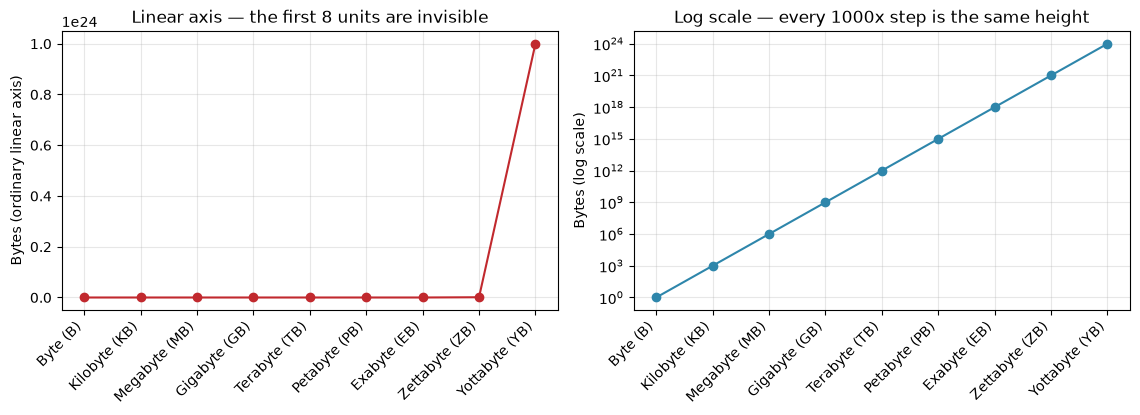

In [6]:
# The same ladder on a log scale. A straight line means "constant multiplication" — 1000x at every step.
fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(11.5, 4.4))

ax_lin.plot(units, bytes_value, marker="o", color="#C1292E")
ax_lin.set_ylabel("Bytes (ordinary linear axis)")
ax_lin.set_title("Linear axis — the first 8 units are invisible")
ax_lin.tick_params(axis="x", rotation=45)
for label in ax_lin.get_xticklabels():
    label.set_ha("right")

ax_log.plot(units, bytes_value, marker="o", color="#2E86AB")
ax_log.set_yscale("log")
ax_log.set_ylabel("Bytes (log scale)")
ax_log.set_title("Log scale — every 1000x step is the same height")
ax_log.tick_params(axis="x", rotation=45)
for label in ax_log.get_xticklabels():
    label.set_ha("right")

plt.show()

**How to read it:** the two panels plot *identical numbers*. On the left, every unit from byte to exabyte is
crushed flat against zero and the chart tells you nothing except "the last one is huge." On the right, the log
scale converts each ×1000 into a fixed vertical step, so the constant multiplication shows up as a straight
line and all nine units are readable at once.

This is your first practical lesson in data visualization, three chapters early: **when values span many
orders of magnitude, a linear axis hides almost all of your data.** We come back to this properly in
Chapter 7.

### 2.1 A trap: 1 KB = 1000 bytes, or 1024?

Both, unfortunately, depending on who is counting — and this is a genuine source of confusion, not a pedantic
detail.

- **Decimal (SI) prefixes** — KB, MB, GB, TB — officially step by **1000**. Disk manufacturers, network
  speeds, and most published statistics use these.
- **Binary prefixes** — KiB, MiB, GiB, TiB — step by **1024** (= 2¹⁰). Operating systems and memory sizes use
  these, but Windows confusingly *labels* them "KB", "MB", "GB".

This is why a "1 TB" hard drive shows up in your file manager as about 931 GB. Nothing is missing; the drive
holds 1,000,000,000,000 bytes and the operating system is dividing by 1024 three times instead of 1000.

Note that the lecture's 97 ZB worked example (next section) uses the **1024** convention. Keep the two straight
and always state which one you used.

In [7]:
# How far apart do the two conventions drift as the unit gets bigger?
rows = []
for i, name in enumerate(["K", "M", "G", "T", "P", "E", "Z", "Y"], start=1):
    decimal_bytes = 1000 ** i
    binary_bytes = 1024 ** i
    rows.append({
        "Decimal": f"1 {name}B",
        "= bytes": f"{decimal_bytes:,}",
        "Binary": f"1 {name}iB",
        "= bytes ": f"{binary_bytes:,}",
        "Binary is larger by": f"{(binary_bytes / decimal_bytes - 1) * 100:.1f}%",
    })

pd.DataFrame(rows)

,Decimal,= bytes,Binary,= bytes,Binary is larger by
0,1 KB,"1,000",1 KiB,"1,024",2.4%
1,1 MB,"1,000,000",1 MiB,"1,048,576",4.9%
2,1 GB,"1,000,000,000",1 GiB,"1,073,741,824",7.4%
3,1 TB,"1,000,000,000,000",1 TiB,"1,099,511,627,776",10.0%
4,1 PB,"1,000,000,000,000,000",1 PiB,"1,125,899,906,842,624",12.6%
5,1 EB,"1,000,000,000,000,000,000",1 EiB,"1,152,921,504,606,846,976",15.3%
6,1 ZB,"1,000,000,000,000,000,000,000",1 ZiB,"1,180,591,620,717,411,303,424",18.1%
7,1 YB,"1,000,000,000,000,000,000,000,000",1 YiB,"1,208,925,819,614,629,174,706,176",20.9%


In [8]:
# The "missing" space on a 1 TB drive, explained in one calculation.
advertised_bytes = 1_000_000_000_000          # what the manufacturer sells: 1 TB, decimal
shown_gib = advertised_bytes / 1024 ** 3      # what the operating system displays, labeled "GB"

print(f"Drive holds        : {advertised_bytes:,} bytes (advertised as 1 TB)")
print(f"OS displays        : {shown_gib:,.1f} 'GB' (really GiB)")
print(f"Apparently missing : {1000 - shown_gib:,.1f} 'GB' — but no bytes were lost, only relabeled.")

Drive holds        : 1,000,000,000,000 bytes (advertised as 1 TB)
OS displays        : 931.3 'GB' (really GiB)
Apparently missing : 68.7 'GB' — but no bytes were lost, only relabeled.


**How to read it:** the drift compounds. At the kilobyte level the two conventions differ by 2.4%; by the
yottabyte level, binary is 21% larger. On a global-scale figure such as "97 ZB," choosing the wrong convention
changes your answer by roughly a fifth — larger than most of the effects you will be trying to measure.

### 2.2 Worked example — how many computers to store 97 ZB?

The lecture asks: *in 2022, the data created, captured, copied, and consumed worldwide reached 97 ZB. How many
computers would we need to store that, if each computer holds 1 TB?*

Using the conversions from the slide (binary, 1024 per step):

$$97\ \text{ZB} \times \frac{1024\ \text{EB}}{1\ \text{ZB}} \times \frac{1024\ \text{PB}}{1\ \text{EB}} \times \frac{1024\ \text{TB}}{1\ \text{PB}} = 104{,}152{,}956{,}928\ \text{TB}$$

In [9]:
zb_total = 97
tb_per_computer = 1

total_tb = zb_total * 1024 * 1024 * 1024          # ZB -> EB -> PB -> TB
computers_needed = total_tb / tb_per_computer

print(f"97 ZB = {total_tb:,} TB")
print(f"Computers needed (1 TB each): {computers_needed:,.0f}")
print(f"That's about {computers_needed / 1e9:.2f} billion computers.")

world_population = 8.0e9
print(f"\nWorld population: about {world_population:,.0f} people")
print(f"Computers per person: {computers_needed / world_population:.1f}")

97 ZB = 104,152,956,928 TB
Computers needed (1 TB each): 104,152,956,928
That's about 104.15 billion computers.

World population: about 8,000,000,000 people
Computers per person: 13.0


**How to read it:** roughly 104 billion 1-TB computers — over thirteen dedicated computers for every single
person on Earth, just to hold **one year's** worth of the planet's data. That is the intuition the lecture
wants you to walk away with. Big data is not "a big Excel file"; it is a scale that breaks the idea of a single
machine entirely.

#### Extending the example: it isn't only about storage

Storing the data is the easy half. The cell below asks two follow-up questions the slide does not:

1. If you had to *move* 97 ZB over a fast 100 Gbit/s link, how long would that take?
2. What would 97 ZB of cloud storage cost for one month, at a typical published rate?

Both answers explain why serious big-data systems try hard to move the *computation* to the data, rather than
moving the data to the computation.

In [10]:
total_bytes = zb_total * 1024 ** 3 * 1e12   # 97 ZB expressed in bytes (TB -> bytes, decimal)

# 1. Transfer time over a very fast 100 Gbit/s link, running flat out with no overhead.
link_bits_per_second = 100e9
transfer_seconds = total_bytes * 8 / link_bits_per_second
print(f"Transfer over a 100 Gbit/s link : {transfer_seconds / 31_557_600:,.0f} years")

# 2. Storage cost for one month at a representative cloud price.
usd_per_gb_month = 0.023
total_gb = total_bytes / 1e9
monthly_cost = total_gb * usd_per_gb_month
print(f"Cloud storage for one month     : USD {monthly_cost:,.0f}")
print(f"                                  (about {monthly_cost / 1e12:,.1f} trillion dollars)")

# For scale: roughly the size of the entire world economy.
world_gdp = 105e12
print(f"\nWorld GDP is about USD {world_gdp:,.0f}, so one month of storage would cost")
print(f"about {monthly_cost / world_gdp:,.0f}x the entire world economy.")

Transfer over a 100 Gbit/s link : 264,033 years
Cloud storage for one month     : USD 2,395,518,009,344
                                  (about 2.4 trillion dollars)

World GDP is about USD 105,000,000,000,000, so one month of storage would cost
about 0x the entire world economy.


**How to read it:** the numbers are deliberately absurd, and the absurdity is the lesson. Nobody stores "all
the world's data" in one place, and nobody could afford to. Real systems keep data where it is produced,
process it in place, discard most of it quickly, and keep only summaries. When you hear that a company
"analyzes petabytes," they are almost never holding petabytes still — they are streaming past it.

> ✏️ **Try it:** the same slide notes that the figure was ~64 ZB in 2020. Re-run the calculations with
> `zb_total = 64` and compare. Then work out how many *years* of 2020-scale data one year of 2022-scale data
> is worth.

---
## 3. Where big data comes from — the three primary sources

Every byte of big data traces back to one of three origins:

| Source | Definition | Typical examples | Who generates it |
|---|---|---|---|
| **Social data** | Collected from users' public activity on social media | Posts, likes, comments, shares, hashtags, follows | People, deliberately |
| **Machine data** | Automatically generated by the activities of networked machines and devices | Sensor readings, server logs, GPS traces, IoT telemetry, app events | Machines, continuously |
| **Transactional data** | Generated by all the daily transactions that take place, online and offline | Purchases, payments, invoices, bookings, refunds, bank transfers | Business processes |

Three things are worth noticing about this split:

- **Volume order.** Machine data is usually by far the largest of the three, because machines never sleep and
  never get bored. A single busy web server can emit more log lines per day than a mid-sized company has
  customers.
- **Reliability order.** Transactional data is usually the cleanest and most trustworthy — money is involved,
  so someone has already checked it. Social data is the messiest: sarcasm, bots, duplicates, deleted posts.
- **Consent.** Social data is about identifiable people, which makes it the most legally and ethically
  constrained of the three. Chapter 2 returns to this.

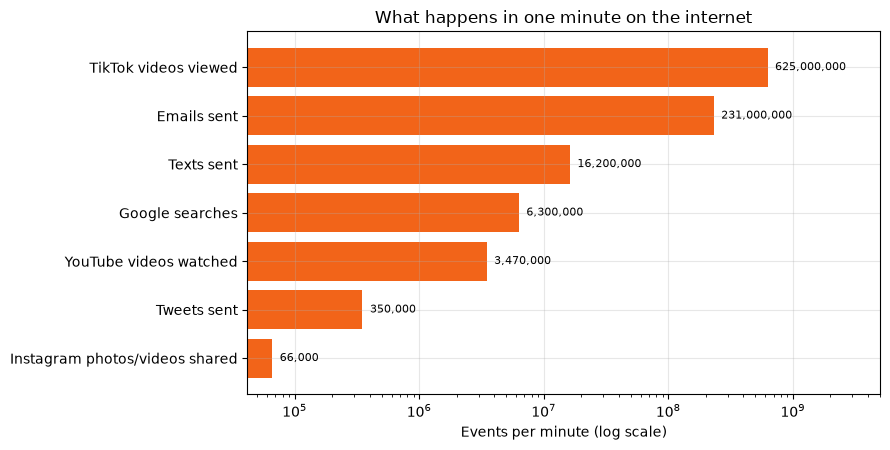

In [11]:
# A snapshot of "what happens in one minute on the internet" (from the lecture's infographic).
per_minute = pd.Series({
    "TikTok videos viewed": 625_000_000,
    "Emails sent": 231_000_000,
    "Texts sent": 16_200_000,
    "Google searches": 6_300_000,
    "YouTube videos watched": 3_470_000,
    "Tweets sent": 350_000,
    "Instagram photos/videos shared": 66_000,
}).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.barh(per_minute.index, per_minute.values, color="#F26419")
ax.set_xscale("log")
ax.set_xlabel("Events per minute (log scale)")
ax.set_title("What happens in one minute on the internet")
for bar, value in zip(bars, per_minute.values):
    ax.text(value * 1.15, bar.get_y() + bar.get_height() / 2,
            f"{value:,}", va="center", fontsize=8)
ax.set_xlim(right=per_minute.max() * 8)
plt.show()

**How to read it:** even the *smallest* bar — 66,000 Instagram shares — is 66,000 new pieces of data every
sixty seconds. The log axis is doing the same job as in Section 2: TikTok's 625 million and Instagram's 66,000
are nearly four orders of magnitude apart and would not fit on one linear chart.

In [12]:
# Scale those per-minute rates up to a day and a year.
minutes_per_day = 60 * 24
minutes_per_year = minutes_per_day * 365

firehose = pd.DataFrame({
    "Per minute": per_minute,
    "Per day": per_minute * minutes_per_day,
    "Per year": per_minute * minutes_per_year,
}).sort_values("Per minute", ascending=False)

# Format with thousands separators so the magnitudes are readable at a glance.
firehose.apply(lambda column: column.map("{:,.0f}".format))

,Per minute,Per day,Per year
TikTok videos viewed,"625,000,000","900,000,000,000","328,500,000,000,000"
Emails sent,"231,000,000","332,640,000,000","121,413,600,000,000"
Texts sent,"16,200,000","23,328,000,000","8,514,720,000,000"
Google searches,"6,300,000","9,072,000,000","3,311,280,000,000"
YouTube videos watched,"3,470,000","4,996,800,000","1,823,832,000,000"
Tweets sent,"350,000","504,000,000","183,960,000,000"
Instagram photos/videos shared,"66,000","95,040,000","34,689,600,000"


**How to read it:** annual figures land in the hundreds of trillions. And this table covers *social data
only* — one of the three sources, and not the biggest one. Machine data (every sensor, every server log,
every GPS ping) dwarfs it.

> ✏️ **Try it:** add a row for a machine-data source — say, a fleet of 10,000 delivery scooters each reporting
> its GPS position once per second. How many events per minute is that, and where does it land on the chart?

### 3.1 Practice — classify the source

Being able to name the source matters because it predicts what the data will be like before you ever open it.
Work through the classification below, then check the code's answer.

In [13]:
records = pd.DataFrame({
    "Record": [
        "A customer pays 120 THB for a coffee with a QR code",
        "A retweet of a university announcement",
        "A smart electricity meter reports 0.4 kWh used this hour",
        "A refund is issued for a cancelled hotel booking",
        "A delivery scooter's GPS pings its location",
        "Someone comments '555' on a Facebook post",
        "A web server logs a 404 error",
        "A student tops up their campus card",
    ],
    "Source": [
        "Transactional", "Social", "Machine", "Transactional",
        "Machine", "Social", "Machine", "Transactional",
    ],
})

print(records["Source"].value_counts().to_string(), "\n")
records

Source
Transactional    3
Machine          3
Social           2 



,Record,Source
0,A customer pays 120 THB for a coffee with a QR...,Transactional
1,A retweet of a university announcement,Social
2,A smart electricity meter reports 0.4 kWh used...,Machine
3,A refund is issued for a cancelled hotel booking,Transactional
4,A delivery scooter's GPS pings its location,Machine
5,Someone comments '555' on a Facebook post,Social
6,A web server logs a 404 error,Machine
7,A student tops up their campus card,Transactional


**How to read it:** the useful signal is *who or what created the record*. A person choosing to express
something → social. A machine reporting its own state without being asked → machine. An exchange of value
between two parties → transactional. The same underlying event can produce all three: buying a coffee creates
a transaction record, the point-of-sale terminal writes a machine log, and a photo of the latte becomes social
data.

---
## 4. How fast is data growing?

The lecture shows the total volume of data created, captured, copied, and consumed worldwide from 2010 to
2020, in zettabytes — growth of roughly 3,110% over the decade. Let's rebuild that chart from the slide's own
numbers and then measure the growth properly.

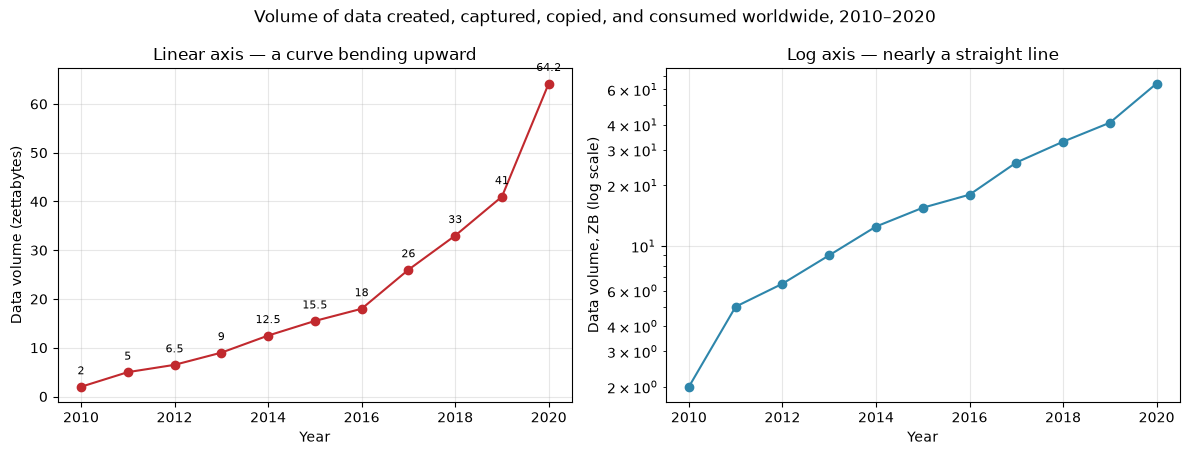

In [14]:
years = list(range(2010, 2021))
zb_volume = [2, 5, 6.5, 9, 12.5, 15.5, 18, 26, 33, 41, 64.2]   # from the lecture slide

fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(12, 4.6))

ax_lin.plot(years, zb_volume, marker="o", color="#C1292E")
for x, y in zip(years, zb_volume):
    ax_lin.annotate(f"{y}", (x, y), textcoords="offset points", xytext=(0, 9),
                    ha="center", fontsize=8)
ax_lin.set_ylabel("Data volume (zettabytes)")
ax_lin.set_xlabel("Year")
ax_lin.set_title("Linear axis — a curve bending upward")

ax_log.plot(years, zb_volume, marker="o", color="#2E86AB")
ax_log.set_yscale("log")
ax_log.set_ylabel("Data volume, ZB (log scale)")
ax_log.set_xlabel("Year")
ax_log.set_title("Log axis — nearly a straight line")

fig.suptitle("Volume of data created, captured, copied, and consumed worldwide, 2010–2020")
plt.show()

**How to read it:** the left panel bends upward — each year adds more than the year before. The right panel is
the diagnostic: on a log axis the same series is close to a straight line, and a straight line on a log axis
means **constant percentage growth**, i.e. exponential. That is a genuinely different beast from linear growth,
and it is why capacity planning in this field is so hard: a system sized comfortably for today can be
undersized within two years without anything "going wrong."

In [15]:
# Measure the growth three ways.
total_growth_pct = (zb_volume[-1] / zb_volume[0] - 1) * 100
n_years = years[-1] - years[0]
cagr = (zb_volume[-1] / zb_volume[0]) ** (1 / n_years) - 1
doubling_years = np.log(2) / np.log(1 + cagr)

print(f"Total growth 2010 -> 2020 : {total_growth_pct:,.0f}%  (a {zb_volume[-1]/zb_volume[0]:.1f}x increase)")
print(f"Compound annual growth    : {cagr * 100:.1f}% per year")
print(f"Doubling time             : every {doubling_years:.1f} years")

Total growth 2010 -> 2020 : 3,110%  (a 32.1x increase)
Compound annual growth    : 41.5% per year
Doubling time             : every 2.0 years


**How to read it:** three numbers describing the same curve, and the third is the most useful one. "Grew
3,110%" is impressive but hard to act on. **"Doubles roughly every two years"** is a planning rule: whatever
storage you have today, you will need twice as much before a typical student finishes a degree.

The **CAGR** (compound annual growth rate) is the constant yearly rate that would take you from the first
value to the last:

$$\text{CAGR} = \left(\frac{V_{\text{end}}}{V_{\text{start}}}\right)^{1/n} - 1$$

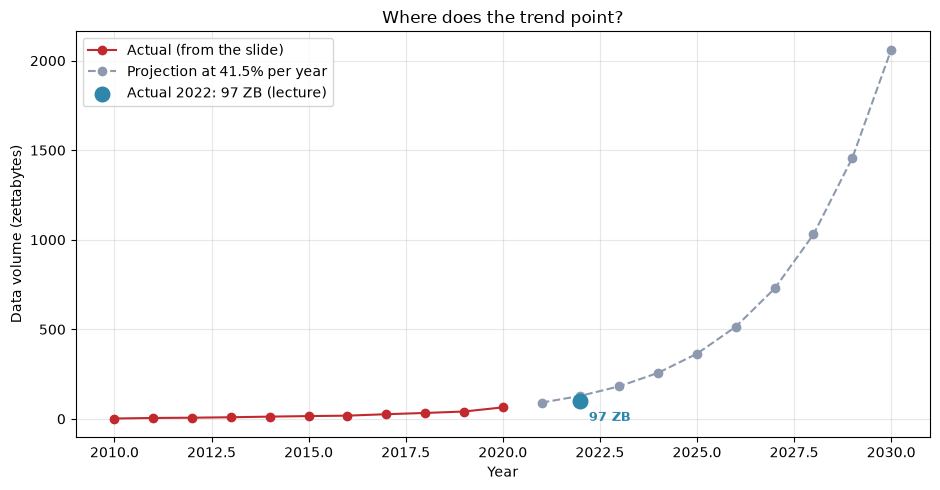

Projection for 2022 : 128.5 ZB
Reported for 2022   : 97.0 ZB
Projection for 2030 : 2,061 ZB


In [16]:
# Project the trend forward at the measured CAGR, and mark the real 2022 figure from the lecture.
future_years = list(range(2021, 2031))
projected = [zb_volume[-1] * (1 + cagr) ** (y - years[-1]) for y in future_years]

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(years, zb_volume, marker="o", color="#C1292E", label="Actual (from the slide)")
ax.plot(future_years, projected, marker="o", linestyle="--", color="#8D99AE",
        label=f"Projection at {cagr*100:.1f}% per year")
ax.scatter([2022], [97], s=110, color="#2E86AB", zorder=5,
           label="Actual 2022: 97 ZB (lecture)")
ax.annotate("97 ZB", (2022, 97), textcoords="offset points", xytext=(6, -14),
            fontsize=9, color="#2E86AB", fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Data volume (zettabytes)")
ax.set_title("Where does the trend point?")
ax.legend()
plt.show()

print(f"Projection for 2022 : {zb_volume[-1] * (1 + cagr) ** 2:.1f} ZB")
print(f"Reported for 2022   : 97.0 ZB")
print(f"Projection for 2030 : {projected[-1]:,.0f} ZB")

**How to read it:** and here is the honest result — the projection says 128.5 ZB for 2022 while the reported
figure is 97 ZB. The model overshoots by about a third after only **two** years of extrapolation, which means
growth had already begun to slow relative to the 2010–2020 average.

Take that seriously. Exponential extrapolation is the most seductive and most frequently wrong move in data
analysis: every exponential curve in the real world eventually flattens when it meets some physical or
economic limit, and the projection only tells you what happens *if nothing changes* — which is never quite
true. By 2030 the dashed line reaches 2,061 ZB. Given that it is already a third too high at two years, treat
that number as an illustration of the method, not a forecast.

> ✏️ **Try it:** append the real 2022 value to the data (`years.append(2022)`, `zb_volume.append(97)`, and
> interpolate 2021 as, say, `79`) and re-run the CAGR cell. Does the growth rate go up or down when the newest
> years are included?

---
## 5. Applications — big data across every sector

Big data shows up in essentially every sector: **banking and finance, healthcare, education, government,
retail, transportation, insurance**. The pattern is always the same shape — a decision that used to be made on
intuition or on a small sample is now made on a full population of records.

In [17]:
applications = pd.DataFrame([
    ("Banking & Finance", "Fraud detection",        "Flag a card transaction that does not fit the holder's pattern"),
    ("Banking & Finance", "Credit scoring",         "Estimate default risk from transaction and repayment history"),
    ("Healthcare",        "Outbreak tracking",      "Live dashboards of case counts by district, updated hourly"),
    ("Healthcare",        "Readmission risk",       "Predict which discharged patients are likely to return"),
    ("Education",         "Early-warning systems",  "Spot students at risk of dropping out from activity logs"),
    ("Government",        "Traffic management",     "Retime signals from live sensor counts"),
    ("Retail",            "Recommendation systems", "Suggest the next product from what similar customers bought"),
    ("Retail",            "Site selection",         "Choose a new store location from demographic and traffic data"),
    ("Transportation",    "Route optimization",     "Re-plan delivery routes from live GPS and traffic feeds"),
    ("Insurance",         "Usage-based pricing",    "Set premiums from telematics rather than age brackets"),
], columns=["Sector", "Application", "What the data actually decides"])

applications

,Sector,Application,What the data actually decides
0,Banking & Finance,Fraud detection,Flag a card transaction that does not fit the ...
1,Banking & Finance,Credit scoring,Estimate default risk from transaction and rep...
2,Healthcare,Outbreak tracking,"Live dashboards of case counts by district, up..."
3,Healthcare,Readmission risk,Predict which discharged patients are likely t...
4,Education,Early-warning systems,Spot students at risk of dropping out from act...
5,Government,Traffic management,Retime signals from live sensor counts
6,Retail,Recommendation systems,Suggest the next product from what similar cus...
7,Retail,Site selection,Choose a new store location from demographic a...
8,Transportation,Route optimization,Re-plan delivery routes from live GPS and traf...
9,Insurance,Usage-based pricing,Set premiums from telematics rather than age b...


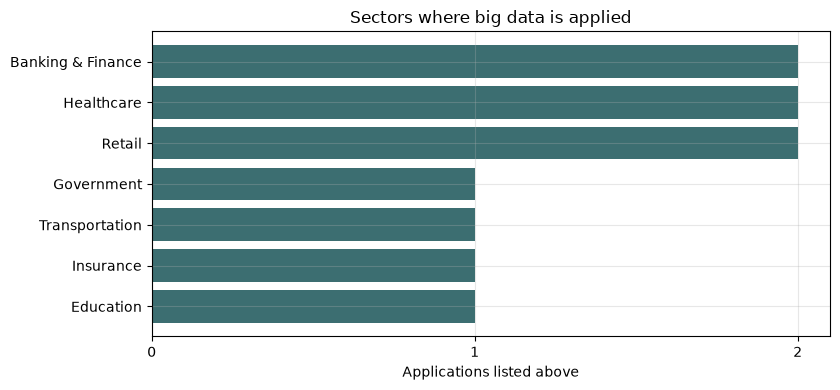

In [18]:
# How many of these applications fall in each sector?
counts = applications["Sector"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.barh(counts.index, counts.values, color="#3C6E71")
ax.set_xlabel("Applications listed above")
ax.set_title("Sectors where big data is applied")
ax.set_xticks(range(0, counts.max() + 1))
plt.show()

**How to read it:** the counts here reflect what this table happens to list, not the true size of each
industry's data — a bar chart of a sample of examples is not a measurement. Be careful of exactly this move
when you read published charts: always ask what the bars are counting.

### 5.1 Starbucks — site selection, menu design, and personalized offers

Starbucks uses big data in three distinct ways, and they are worth separating because they use different data
and answer different questions:

1. **Real-estate site selection (GIS).** Before opening a store, Starbucks combines demographics, income
   levels, foot and vehicle traffic, public-transport routes, and the locations of existing stores (including
   its own — cannibalization matters) in a geographic information system. The question is *"how much revenue
   would a store at this exact corner make?"*
2. **Menu design and optimization.** Sales data by store, hour, season, and weather drives which items are
   offered where. A drink that sells in Bangkok in April is not the same one that sells in Chiang Mai in
   December.
3. **Personalized rewards-app offers.** Individual purchase history feeds targeted offers. The interesting
   part is that the goal is not to give you a discount on what you already buy — that costs money and changes
   nothing — but to nudge you toward a *different* purchase.

Below is a small simulated version of the site-selection question, so you can see how several signals combine
into one score.

In [19]:
# A deliberately simple site-selection model over simulated candidate locations.
n_sites = 12
sites = pd.DataFrame({
    "Site": [f"Site {i+1}" for i in range(n_sites)],
    "Foot traffic (per hour)": rng.integers(80, 900, n_sites),
    "Median income (k THB/mo)": rng.integers(15, 70, n_sites),
    "Nearest own store (km)": np.round(rng.uniform(0.2, 4.0, n_sites), 1),
    "Rent (k THB/mo)": rng.integers(30, 160, n_sites),
})

# Put every column on a 0-1 scale so they can be combined; a raw sum would let
# "rent in thousands" swamp "distance in kilometers" for no good reason.
def normalize(column):
    return (column - column.min()) / (column.max() - column.min())

sites["Score"] = (
    0.40 * normalize(sites["Foot traffic (per hour)"])
    + 0.25 * normalize(sites["Median income (k THB/mo)"])
    + 0.20 * normalize(sites["Nearest own store (km)"])   # farther from our own store is better
    - 0.15 * normalize(sites["Rent (k THB/mo)"])          # cheaper is better, so this subtracts
).round(3)

sites.sort_values("Score", ascending=False).reset_index(drop=True)

,Site,Foot traffic (per hour),Median income (k THB/mo),Nearest own store (km),Rent (k THB/mo),Score
0,Site 7,894,40,2.4,69,0.666
1,Site 3,598,38,2.5,109,0.456
2,Site 10,493,47,1.0,65,0.440
3,Site 9,238,42,1.7,70,0.313
4,Site 4,290,50,0.8,98,0.304
5,Site 5,111,28,3.6,42,0.302
6,Site 8,84,46,3.2,110,0.302
7,Site 12,536,20,1.8,79,0.292
8,Site 11,429,34,2.4,150,0.280
9,Site 1,138,43,0.3,44,0.222


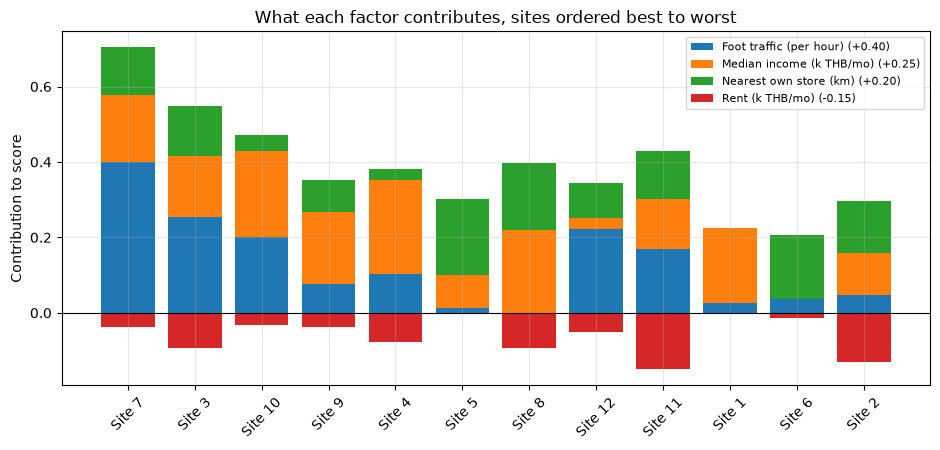

In [20]:
# Which signal is actually driving the ranking?
ranked = sites.sort_values("Score", ascending=False)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
factors = ["Foot traffic (per hour)", "Median income (k THB/mo)",
           "Nearest own store (km)", "Rent (k THB/mo)"]
weights = [0.40, 0.25, 0.20, -0.15]
bottom_pos = np.zeros(len(ranked))
bottom_neg = np.zeros(len(ranked))

for factor, weight in zip(factors, weights):
    contribution = weight * normalize(sites[factor])[ranked.index].values
    base = bottom_pos if weight > 0 else bottom_neg
    ax.bar(ranked["Site"], contribution, bottom=base, label=f"{factor} ({weight:+.2f})")
    if weight > 0:
        bottom_pos = bottom_pos + contribution
    else:
        bottom_neg = bottom_neg + contribution

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Contribution to score")
ax.set_title("What each factor contributes, sites ordered best to worst")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8, loc="upper right")
plt.show()

**How to read it:** each bar is one candidate site, split into the four things the model cares about. Bars
above zero help the site; the rent bar hangs below zero because high rent hurts. The winning sites are the
ones with a tall foot-traffic block that is not cancelled by rent.

Two honest caveats, which matter more than the model:

- **The weights are made up.** `0.40` for foot traffic is a guess, not a measurement. A real model would learn
  these weights from the revenue of stores already open — that is a *supervised learning* problem, and it is
  Chapter 10.
- **Normalizing changes the meaning.** After scaling, "best rent among these twelve sites" scores 0, not "cheap
  in absolute terms." Add a thirteenth, wildly expensive site and every existing score shifts.

> ✏️ **Try it:** change the foot-traffic weight from `0.40` to `0.15` and the rent weight from `-0.15` to
> `-0.40`, then re-run both cells. Does the top-ranked site change? What does that tell you about how much
> trust a scoring model like this deserves?

### 5.2 Netflix and Amazon — how a recommendation engine actually works

The lecture names two families of recommender:

- **Collaborative filtering** — "people *similar to you* liked this." It uses the ratings matrix only, and
  knows nothing about what the items actually are.
- **Content-based filtering** — "this item is *similar to things you already liked*." It uses item features
  (genre, actors, description) and your own history only.

They fail in opposite ways, which is why real systems use both. Let's build each one from scratch on a tiny
dataset — the mathematics fits in a few lines.

In [21]:
# A tiny ratings matrix: 6 users x 6 movies, on a 1-5 scale. NaN means "not rated".
movies = ["Sci-Fi Epic", "Space Sequel", "Rom-Com A", "Rom-Com B", "Thai Horror", "Docu: Oceans"]
users = ["Anong", "Boonmee", "Chai", "Duan", "Eak", "Fah"]

ratings = pd.DataFrame([
    [5, 5, 1, 1, 2, 4],
    [4, 5, 2, 1, 1, 5],
    [1, 1, 5, 5, 3, 2],
    [2, 1, 4, 5, 2, 1],
    [5, 4, 1, np.nan, 5, 3],
    [1, 2, 5, 4, np.nan, 2],
], index=users, columns=movies, dtype=float)

ratings

,Sci-Fi Epic,Space Sequel,Rom-Com A,Rom-Com B,Thai Horror,Docu: Oceans
Anong,5.0,5.0,1.0,1.0,2.0,4.0
Boonmee,4.0,5.0,2.0,1.0,1.0,5.0
Chai,1.0,1.0,5.0,5.0,3.0,2.0
Duan,2.0,1.0,4.0,5.0,2.0,1.0
Eak,5.0,4.0,1.0,NaN,5.0,3.0
Fah,1.0,2.0,5.0,4.0,NaN,2.0


In [22]:
def cosine_similarity(a, b):
    # Cosine similarity over the items *both* vectors have rated.
    both = a.notna() & b.notna()
    if both.sum() == 0:
        return 0.0
    x, y = a[both], b[both]
    denominator = np.sqrt((x ** 2).sum()) * np.sqrt((y ** 2).sum())
    return float((x * y).sum() / denominator) if denominator else 0.0

# Similarity of every user to every other user.
user_sim = pd.DataFrame(
    [[cosine_similarity(ratings.loc[u], ratings.loc[v]) for v in users] for u in users],
    index=users, columns=users,
).round(3)

user_sim

,Anong,Boonmee,Chai,Duan,Eak,Fah
Anong,1.000,0.972,0.497,0.528,0.926,0.549
Boonmee,0.972,1.000,0.541,0.545,0.844,0.638
Chai,0.497,0.541,1.000,0.973,0.635,0.983
Duan,0.528,0.545,0.973,1.000,0.697,0.949
Eak,0.926,0.844,0.635,0.697,1.000,0.576
Fah,0.549,0.638,0.983,0.949,0.576,1.000


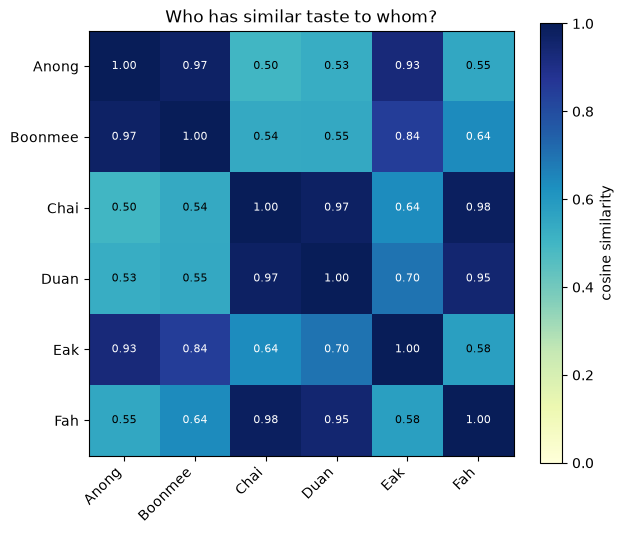

In [23]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))
image = ax.imshow(user_sim.values, cmap="YlGnBu", vmin=0, vmax=1)
ax.set_xticks(range(len(users)), users, rotation=45, ha="right")
ax.set_yticks(range(len(users)), users)
for i in range(len(users)):
    for j in range(len(users)):
        value = user_sim.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if value > 0.6 else "black")
ax.set_title("Who has similar taste to whom?")
ax.grid(False)
fig.colorbar(image, ax=ax, label="cosine similarity")
plt.show()

**How to read it:** the diagonal is 1.00 — everyone is identical to themselves. Off the diagonal, two clear
blocks appear: Anong, Boonmee, and Eak like the science-fiction films; Chai, Duan, and Fah like the romantic
comedies. **Nothing in the calculation knows what a genre is.** The clustering emerged purely from who rated
what similarly, which is exactly the appeal of collaborative filtering: it discovers taste groups you never
told it about.

In [24]:
def predict_collaborative(user, movie, k=2):
    # Predict a rating as the similarity-weighted average of the k most similar users who rated it.
    others = ratings[movie].dropna().drop(index=user, errors="ignore")
    if others.empty:
        return np.nan
    similarities = user_sim.loc[user, others.index].sort_values(ascending=False).head(k)
    if similarities.sum() == 0:
        return np.nan
    return float((similarities * others[similarities.index]).sum() / similarities.sum())

# Eak has not rated "Rom-Com B"; Fah has not rated "Thai Horror".
for user, movie in [("Eak", "Rom-Com B"), ("Fah", "Thai Horror")]:
    predicted = predict_collaborative(user, movie)
    print(f"{user:8s} -> {movie:12s} : predicted {predicted:.2f} / 5")

print("\nRecommendations for Eak (unseen movies, best first):")
unseen = ratings.loc["Eak"][ratings.loc["Eak"].isna()].index
for movie in unseen:
    print(f"  {movie:14s} predicted {predict_collaborative('Eak', movie):.2f}")

Eak      -> Rom-Com B    : predicted 1.00 / 5
Fah      -> Thai Horror  : predicted 2.51 / 5

Recommendations for Eak (unseen movies, best first):
  Rom-Com B      predicted 1.00


**How to read it:** Eak is predicted to dislike "Rom-Com B" (~1.0/5), because the users most similar to Eak —
Anong and Boonmee — both rated it 1. No one had to tell the system that Eak dislikes romantic comedies; it
inferred it from company kept.

In [25]:
# Content-based filtering: describe each movie by its features, ignore other users entirely.
features = pd.DataFrame([
    #            sci-fi  romance  horror  documentary  sequel
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 1],
    [0, 1, 0, 0, 0],
    [0, 1, 0, 0, 1],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
], index=movies, columns=["sci-fi", "romance", "horror", "documentary", "sequel"], dtype=float)

def content_profile(user):
    # A user's taste = their ratings, centered, used to weight the features of what they rated.
    seen = ratings.loc[user].dropna()
    weights = seen - seen.mean()          # above-average ratings pull the profile toward those features
    return (features.loc[seen.index].T * weights).T.sum()

def predict_content(user, movie):
    profile = content_profile(user)
    denominator = np.linalg.norm(profile) * np.linalg.norm(features.loc[movie])
    return float(profile @ features.loc[movie] / denominator) if denominator else 0.0

print("Eak's taste profile (positive = likes that feature):")
print(content_profile("Eak").round(2).to_string())

print("\nContent-based scores for Eak's unseen movies:")
for movie in unseen:
    print(f"  {movie:14s} similarity {predict_content('Eak', movie):+.2f}")

Eak's taste profile (positive = likes that feature):
sci-fi         1.8
romance       -2.6
horror         1.4
documentary   -0.6
sequel         0.4

Content-based scores for Eak's unseen movies:
  Rom-Com B      similarity -0.44


**How to read it:** the profile says Eak leans toward sci-fi and horror and away from romance — read straight
off the *features* of what Eak rated highly, with no reference to any other user. The two methods agree here,
but they got there by completely different routes, and that difference is what makes combining them worthwhile:

| | Collaborative filtering | Content-based filtering |
|---|---|---|
| **Uses** | The ratings matrix only | Item features + one user's history |
| **Strength** | Finds surprising cross-genre recommendations | Works from the very first rating |
| **Cold start — new user** | ❌ Fails: nobody to compare against | ⚠️ Needs at least one rating |
| **Cold start — new item** | ❌ Fails: nobody has rated it yet | ✅ Fine: features are known on day one |
| **Risk** | Popularity bias — the same hits for everyone | Filter bubble — only ever more of the same |

Real systems (Netflix, Amazon, Shopee, YouTube) run **hybrid** recommenders that blend both, plus popularity,
recency, and business rules.

> ✏️ **Try it:** add a seventh movie, `"Sci-Fi Sequel 2"`, that *nobody* has rated. Ask both methods to score
> it for Eak. Which one can answer at all? That gap is the new-item cold-start problem, and it is why every
> streaming service works hard to tag its catalog.

### 5.3 Healthcare — the COVID dashboards

During the COVID-19 pandemic, live dashboards pulled data from the WHO and national health agencies and
visualized it through a real-time geographic information system to track cases worldwide. They are worth
studying as an engineering artifact, because they made the whole big-data pipeline visible to the public at
once:

- **Sources.** Hundreds of national agencies, each with its own format, language, reporting schedule, and
  definition of "a case."
- **Preparation.** Names reconciled, units aligned, cumulative-versus-daily confusion resolved, negative
  corrections handled when a country revised its own history. This unglamorous step is Chapter 6, and it was
  where nearly all the real work lived.
- **Analysis.** Rolling averages to smooth weekend reporting gaps, per-capita normalization so countries of
  different sizes could be compared.
- **Visualization.** Maps, curves, and comparison charts, refreshed continuously.

The single most repeated mistake in reading those dashboards was comparing **raw counts** between countries of
different sizes. The cell below shows why that is so misleading.

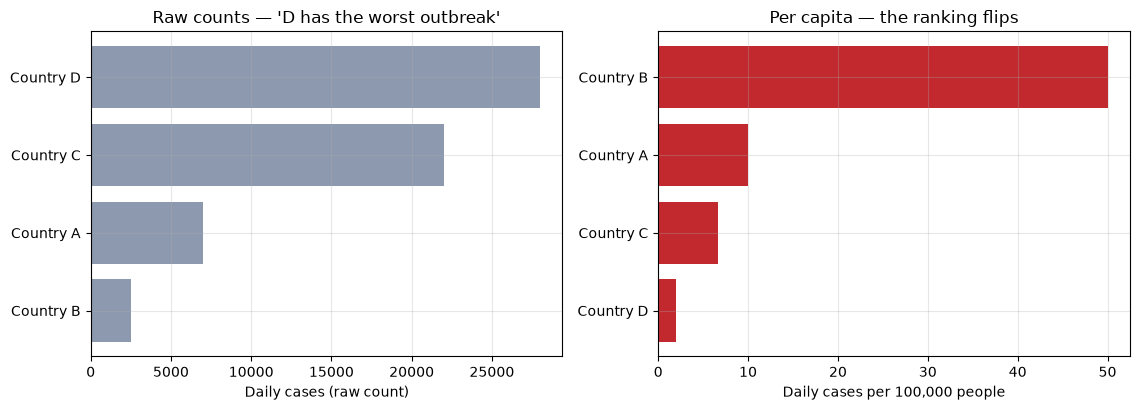

,Country,Population (m),Daily cases,Cases per 100k
0,Country A,70,7000,10.0
1,Country B,5,2500,50.0
2,Country C,330,22000,6.7
3,Country D,1400,28000,2.0


In [26]:
# Simulated daily case counts for four countries of very different populations.
countries = pd.DataFrame({
    "Country": ["Country A", "Country B", "Country C", "Country D"],
    "Population (m)": [70, 5, 330, 1400],
    "Daily cases": [7_000, 2_500, 22_000, 28_000],
})
countries["Cases per 100k"] = (
    countries["Daily cases"] / (countries["Population (m)"] * 1e6) * 100_000
).round(1)

fig, (ax_raw, ax_rate) = plt.subplots(1, 2, figsize=(11.5, 4.2))

order_raw = countries.sort_values("Daily cases")
ax_raw.barh(order_raw["Country"], order_raw["Daily cases"], color="#8D99AE")
ax_raw.set_xlabel("Daily cases (raw count)")
ax_raw.set_title("Raw counts — 'D has the worst outbreak'")

order_rate = countries.sort_values("Cases per 100k")
ax_rate.barh(order_rate["Country"], order_rate["Cases per 100k"], color="#C1292E")
ax_rate.set_xlabel("Daily cases per 100,000 people")
ax_rate.set_title("Per capita — the ranking flips")

plt.show()
countries

**How to read it:** by raw count, Country D looks worst and Country B looks fine. Per capita, the order almost
reverses: Country B has more than four times Country D's rate. Both charts are drawn from the same true
numbers — the difference is entirely in the choice of denominator.

**The lesson generalizes far beyond COVID.** Whenever you compare groups of different sizes — countries,
stores, departments, classes — a raw count is almost always the wrong statistic. Ask "per what?" before you
draw the bar.

---
## 6. Necessary skills — the Data Science Venn diagram

The lecture places the **data scientist** at the intersection of three skill areas:

- **Math & Statistics** — choosing and applying the right methods to extract insight from data.
- **Computer Science** — working with massive amounts of electronic data that must be acquired, cleaned, and
  manipulated.
- **Domain Knowledge** — understanding the specific field you work in: business, healthcare, finance,
  education.

The diagram's real teaching value is in what sits in the *pairwise* overlaps — each is a recognizable, and
usually unhappy, way of working.

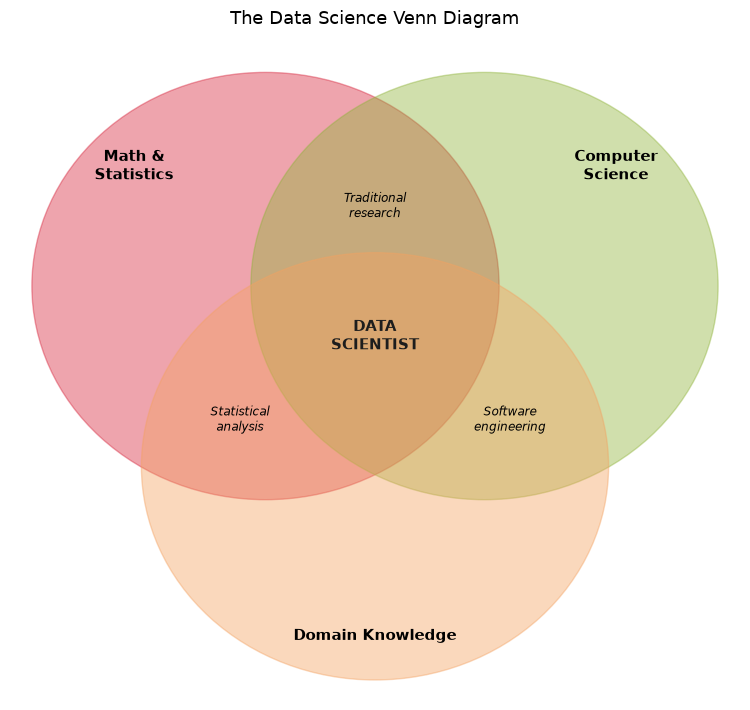

In [27]:
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(7.6, 7.2))
for center, color in [((0.35, 0.62), "#D7263D"), ((0.65, 0.62), "#8FB339"), ((0.50, 0.35), "#F4A261")]:
    ax.add_patch(Circle(center, 0.32, alpha=0.42, color=color))

# The three skill areas.
ax.text(0.17, 0.78, "Math &\nStatistics", ha="center", fontsize=11, fontweight="bold")
ax.text(0.83, 0.78, "Computer\nScience", ha="center", fontsize=11, fontweight="bold")
ax.text(0.50, 0.09, "Domain Knowledge", ha="center", fontsize=11, fontweight="bold")

# The center, and the three pairwise overlaps.
ax.text(0.50, 0.545, "DATA\nSCIENTIST", ha="center", va="center",
        fontsize=11, fontweight="bold", color="#1d1d1d")
ax.text(0.50, 0.74, "Traditional\nresearch", ha="center", va="center", fontsize=8.5, style="italic")
ax.text(0.315, 0.42, "Statistical\nanalysis", ha="center", va="center", fontsize=8.5, style="italic")
ax.text(0.685, 0.42, "Software\nengineering", ha="center", va="center", fontsize=8.5, style="italic")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.grid(False)
ax.set_title("The Data Science Venn Diagram", fontsize=13)
plt.show()

**How to read it:** the closer a role sits to the center, the more it demands *all three* skill areas at once.
That is exactly why "data scientist" job postings ask for statistics, coding, *and* business context — none of
the three alone is enough. The three overlaps are worth naming:

| Overlap | Has | Missing | What goes wrong |
|---|---|---|---|
| **Statistical analysis** | Math & stats + domain | Computer science | Correct methods that cannot be run at scale — everything stays in a spreadsheet |
| **Software engineering** | Computer science + domain | Math & stats | Fast, beautiful pipelines that compute the wrong quantity, confidently |
| **Traditional research** | Math & stats + computer science | Domain | Technically flawless models that answer a question nobody asked |

The third one is the trap most students fall into, and it has no technical fix. If you cannot explain why an
organization should care about your result, the result does not matter — no amount of accuracy rescues it.

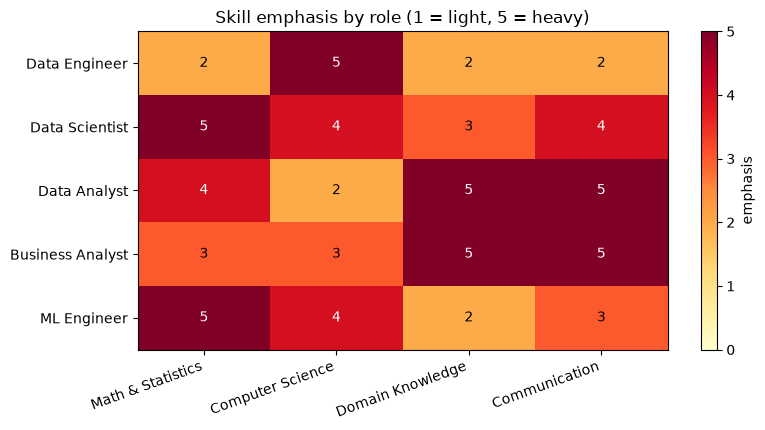

In [28]:
# Roughly how much of each skill do the different roles need?
skills = pd.DataFrame({
    "Math & Statistics":   [2, 5, 4, 3, 5],
    "Computer Science":    [5, 4, 2, 3, 4],
    "Domain Knowledge":    [2, 3, 5, 5, 2],
    "Communication":       [2, 4, 5, 5, 3],
}, index=["Data Engineer", "Data Scientist", "Data Analyst",
          "Business Analyst", "ML Engineer"])

fig, ax = plt.subplots(figsize=(8.2, 4.4))
image = ax.imshow(skills.values, cmap="YlOrRd", vmin=0, vmax=5, aspect="auto")
ax.set_xticks(range(skills.shape[1]), skills.columns, rotation=20, ha="right")
ax.set_yticks(range(skills.shape[0]), skills.index)
for i in range(skills.shape[0]):
    for j in range(skills.shape[1]):
        value = skills.values[i, j]
        ax.text(j, i, value, ha="center", va="center", fontsize=10,
                color="white" if value >= 4 else "black")
ax.set_title("Skill emphasis by role (1 = light, 5 = heavy)")
ax.grid(False)
fig.colorbar(image, ax=ax, label="emphasis")
plt.show()

**How to read it:** read across a row to see what one role needs; read down a column to see who needs a given
skill. Notice that **no row is all 5s** — nobody is expected to max out everything, and choosing which two or
three columns to be genuinely strong in is a reasonable way to plan a career. These ratings are indicative
rather than measured; treat them as a conversation starter, not data.

---
## 7. Big data personnel — three roles, three different jobs

The titles get used loosely in job advertisements, but each role owns a different part of the pipeline.

| Role | What they do | Key requirements |
|---|---|---|
| **Data Engineer** | Prepares data: develops, constructs, tests, and maintains the complete data architecture | Strong programming, cloud computing, big data tools |
| **Data Scientist** | Analyzes and interprets complex data; a "data wrangler" who organizes it | Statistics, mathematics, programming, big data |
| **Data Analyst** | Analyzes numeric data to help companies make better decisions | Communication skills, domain knowledge |

The one-line version, which is worth memorizing:

> **The Data Engineer builds the pipes. The Data Scientist builds the models. The Data Analyst tells the
> story.**

They are sequential in a working organization: the analyst's dashboard is only as good as the scientist's
definitions, which are only as good as the engineer's pipeline. When a number on a dashboard is wrong, the
cause is upstream far more often than not.

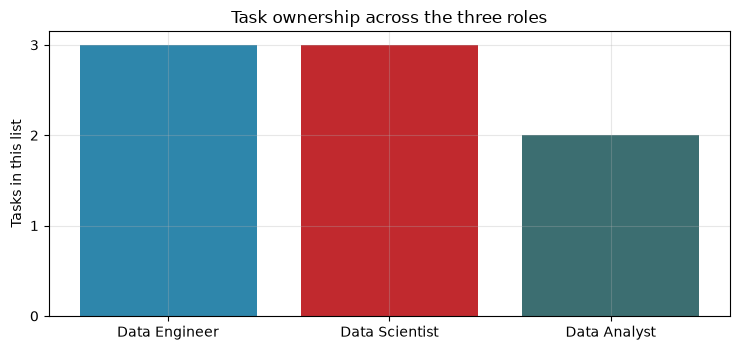

,Task,Usual owner
0,Set up a nightly job that loads sales files in...,Data Engineer
1,Build a model predicting which customers will ...,Data Scientist
2,Prepare the monthly sales dashboard for the ma...,Data Analyst
3,Decide how 'active customer' should be defined,Data Scientist
4,Scale the cluster so last month's query finish...,Data Engineer
5,Explain to the marketing team why last week's ...,Data Analyst
6,Choose between two competing model designs,Data Scientist
7,Fix a pipeline that silently dropped 3% of rows,Data Engineer


In [29]:
# Which role would normally own each task?
tasks = pd.DataFrame({
    "Task": [
        "Set up a nightly job that loads sales files into the warehouse",
        "Build a model predicting which customers will churn",
        "Prepare the monthly sales dashboard for the management meeting",
        "Decide how 'active customer' should be defined",
        "Scale the cluster so last month's query finishes in minutes",
        "Explain to the marketing team why last week's numbers dipped",
        "Choose between two competing model designs",
        "Fix a pipeline that silently dropped 3% of rows",
    ],
    "Usual owner": [
        "Data Engineer", "Data Scientist", "Data Analyst", "Data Scientist",
        "Data Engineer", "Data Analyst", "Data Scientist", "Data Engineer",
    ],
})

fig, ax = plt.subplots(figsize=(7.5, 3.6))
owner_counts = tasks["Usual owner"].value_counts()
ax.bar(owner_counts.index, owner_counts.values,
       color=["#2E86AB", "#C1292E", "#3C6E71"])
ax.set_ylabel("Tasks in this list")
ax.set_title("Task ownership across the three roles")
ax.set_yticks(range(0, owner_counts.max() + 1))
plt.show()

tasks

**How to read it:** notice that "decide how *active customer* should be defined" landed with the data
scientist rather than the engineer. Definition questions look like trivia and are in fact the highest-stakes
decisions in the whole pipeline — change the definition of "active" and every downstream number moves. In
smaller organizations one person wears all three hats; the roles still describe three different *kinds of
work*, even when they share a desk.

---
## 8. Big data vs. data analytics vs. data science

These three terms get used almost interchangeably in casual conversation. The lecture draws a clear line:

| Term | What it is | Grammatical clue | Example sentence |
|---|---|---|---|
| **Big data** | The raw material: any large and complex collection of data | A **noun** — a thing you have | "We store 40 TB of big data." |
| **Data analytics** | The activity: the process of extracting meaningful information from data | A **process** — something you do | "We ran an analytics project on churn." |
| **Data science** | The discipline: a multidisciplinary field aiming to produce broader insights, using analytics as one of its tools | A **field** — something you study | "She has a degree in data science." |

In short: big data is the **raw material**, data analytics is an **activity**, and data science is the
**discipline** that encompasses both. You can have big data without doing analytics (a warehouse full of logs
nobody reads), and you can do analytics without big data (a careful study of 200 survey responses).

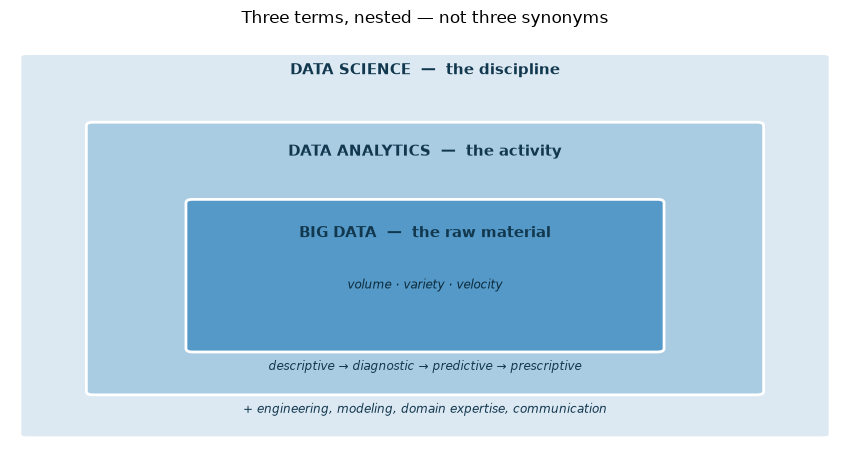

In [30]:
# The relationship, drawn as nested scope rather than three separate boxes.
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(8.6, 4.8))
boxes = [
    (0.02, 0.06, 0.96, 0.88, "#DCE9F2", "DATA SCIENCE  —  the discipline", 0.90),
    (0.10, 0.16, 0.80, 0.62, "#A9CCE3", "DATA ANALYTICS  —  the activity", 0.71),
    (0.22, 0.26, 0.56, 0.34, "#5499C7", "BIG DATA  —  the raw material", 0.52),
]
for x, y, w, h, color, label, label_y in boxes:
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.008",
                                facecolor=color, edgecolor="white", linewidth=2))
    ax.text(0.5, label_y, label, ha="center", fontsize=10.5, fontweight="bold", color="#12384f")

ax.text(0.5, 0.40, "volume · variety · velocity", ha="center", fontsize=8.5,
        style="italic", color="#0d2b3d")
ax.text(0.5, 0.21, "descriptive → diagnostic → predictive → prescriptive",
        ha="center", fontsize=8.5, style="italic", color="#12384f")
ax.text(0.5, 0.11, "+ engineering, modeling, domain expertise, communication",
        ha="center", fontsize=8.5, style="italic", color="#12384f")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.grid(False)
ax.set_title("Three terms, nested — not three synonyms")
plt.show()

**How to read it:** the boxes nest because the terms are not siblings. Data science is the widest — it
contains analytics as one of its activities, and treats big data as one of the materials it works with.
Drawing them side by side (as many textbooks do) suggests they are alternatives, which is the exact confusion
the lecture is trying to remove.

### 8.1 The analytics maturity ladder

Inside "data analytics" there is a well-known progression, and knowing where a question sits tells you
immediately how hard it will be to answer.

| Stage | Question it answers | Example | Difficulty |
|---|---|---|---|
| **Descriptive** | *What happened?* | "Sales fell 12% last month." | Reporting |
| **Diagnostic** | *Why did it happen?* | "The fall was concentrated in one region after a competitor opened." | Investigation |
| **Predictive** | *What will happen?* | "Next month's sales will likely fall a further 5–8%." | Modeling (Chapters 9–11) |
| **Prescriptive** | *What should we do?* | "Shift the promotion budget to that region." | Optimization + judgment |

Most organizations claiming to "do AI" are in fact still working on the first rung — and that is not a
criticism. Reliable descriptive analytics is genuinely valuable and genuinely hard, and every rung above it
rests on the ones below. A prediction built on a broken monthly report is a broken prediction.

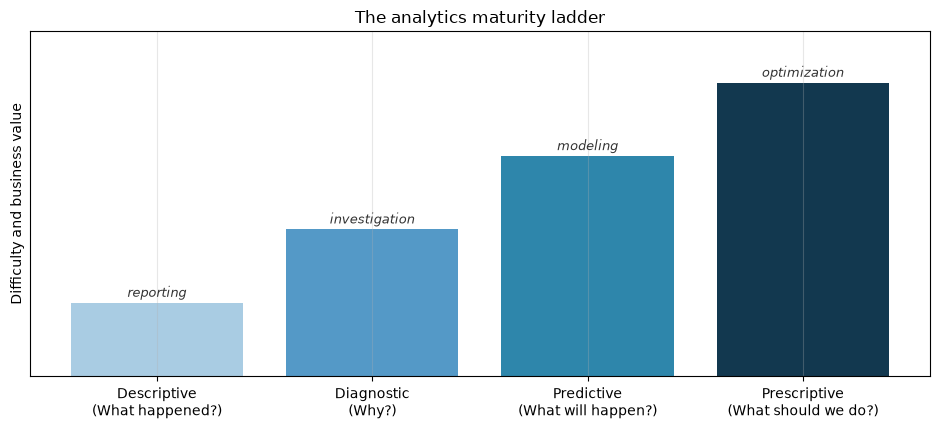

In [31]:
stages = ["Descriptive\n(What happened?)", "Diagnostic\n(Why?)",
          "Predictive\n(What will happen?)", "Prescriptive\n(What should we do?)"]
value = [1, 2, 3, 4]

fig, ax = plt.subplots(figsize=(9.5, 4.4))
bars = ax.bar(stages, value, color=["#A9CCE3", "#5499C7", "#2E86AB", "#12384f"])
for bar, label in zip(bars, ["reporting", "investigation", "modeling", "optimization"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08, label,
            ha="center", fontsize=9, style="italic", color="#333")
ax.set_ylabel("Difficulty and business value")
ax.set_yticks([])
ax.set_ylim(0, 4.7)
ax.set_title("The analytics maturity ladder")
plt.show()

**How to read it:** value and difficulty rise together, and the axis is deliberately unlabeled because there
is no measured scale here — it is a conceptual ordering, not data. Do not let a chart like this convince you
of a precise quantity it never measured.

> ✏️ **Try it:** for each rung, write down one question about *your own* university that would sit on it. Which
> rung was hardest to invent a question for? That is usually the rung your intuition is weakest on.

---
## 9. Glossary

| Term | Meaning |
|---|---|
| **Data** | Raw, unorganized facts collected by observation or experimentation |
| **Big data** | Data at a scale where traditional storage, processing, or analysis tools stop working |
| **DIKW** | Data → Information → Knowledge → Wisdom; the ladder from raw facts to decisions |
| **Social data** | Data from users' public activity on social media |
| **Machine data** | Data generated automatically by networked machines, sensors, and devices |
| **Transactional data** | Data generated by daily business transactions, online and offline |
| **Zettabyte (ZB)** | 10²¹ bytes (decimal) — the unit global data volume is now measured in |
| **KiB / MiB / GiB** | Binary units stepping by 1024, distinct from the decimal KB / MB / GB |
| **CAGR** | Compound annual growth rate — the constant yearly rate implied by a start and end value |
| **Collaborative filtering** | Recommending based on what *similar users* liked |
| **Content-based filtering** | Recommending based on the *features of items* you already liked |
| **Cold start** | A recommender's inability to serve a brand-new user or item with no history |
| **GIS** | Geographic information system — software for analyzing location-tagged data |
| **Data engineer / scientist / analyst** | Builds the pipes / builds the models / tells the story |
| **Descriptive → prescriptive** | The analytics maturity ladder, from *what happened* to *what should we do* |

---
## 10. Check your understanding

Try each question before opening the answer.

**Q1.** A hospital has 3 GB of patient records that open fine in a spreadsheet. Is this big data?

<details><summary>Answer</summary>

No — and note *why*. The test is not the number of gigabytes, it is whether traditional tools still work. The
spreadsheet opens, so the traditional tool is fine. The same 3 GB *would* qualify if it had to be joined
against a national registry in real time on a device that cannot hold it in memory. Big data is relative to
the tools and the task.
</details>

**Q2.** Your phone's storage is advertised as 128 GB, but the settings screen shows 119 GB. Where did 9 GB go?

<details><summary>Answer</summary>

Nowhere — the two screens use different units. The manufacturer counts 128 × 10⁹ bytes (decimal GB); the
operating system divides by 1024³ and labels the result "GB" when it is really GiB. 128 × 10⁹ / 1024³ ≈ 119.2.
Some capacity is also genuinely taken by the operating system, but the unit mismatch explains most of the gap.
</details>

**Q3.** Classify each: (a) a smart meter reporting hourly usage, (b) a refund for a cancelled booking, (c) a
comment on a university Facebook page.

<details><summary>Answer</summary>

(a) machine data — a device reporting its own state unprompted; (b) transactional data — an exchange of value;
(c) social data — a person choosing to express something publicly.
</details>

**Q4.** Global data volume grew from 2 ZB to 64.2 ZB between 2010 and 2020. What is the CAGR, and roughly how
often does the volume double?

<details><summary>Answer</summary>

CAGR = (64.2 / 2)^(1/10) − 1 ≈ 0.417, i.e. about **41.7% per year**. Doubling time = ln 2 / ln(1.417) ≈ **2.0
years**. Re-run the Section 4 cell to confirm.
</details>

**Q5.** A new film is added to a streaming catalog and nobody has rated it. Which recommender can still
suggest it, and why?

<details><summary>Answer</summary>

Content-based filtering. It scores an item from the item's own features (genre, cast, description), all of
which are known on day one. Collaborative filtering needs at least some ratings to compare against, so it is
blind to the new film — the new-item cold-start problem.
</details>

**Q6.** Country A reports 22,000 daily cases and Country B reports 2,500. Which has the worse outbreak?

<details><summary>Answer</summary>

Unanswerable as stated — you need the populations. Raw counts across groups of different sizes are almost
always the wrong comparison; convert to a rate (cases per 100,000 people) first. In the Section 5.3 example the
ranking reversed completely once population was taken into account.
</details>

**Q7.** A dashboard number is wrong. The analyst who built the dashboard, the scientist who defined the
metric, and the engineer who built the pipeline all say it isn't their fault. Where would you look first?

<details><summary>Answer</summary>

Upstream. Errors propagate downward through the pipeline, so a wrong number on a dashboard is most often
caused by something earlier — a pipeline that silently dropped rows, a changed source format, or a metric
definition that no longer matches what the business means. Check that the row counts and the definition are
right before you touch the chart.
</details>

**Q8.** Which rung of the analytics maturity ladder is "our model says churn will rise 4% next quarter"? What
would the next rung up look like?

<details><summary>Answer</summary>

Predictive. The next rung, prescriptive, would be: "…so move 15% of the retention budget to the at-risk
segment," which requires not just a forecast but a set of possible actions and a way to choose among them.
</details>

---
## 11. Summary — key takeaways

1. **Scale changes the tools.** Big data is data at a scale where spreadsheets and single databases stop
   working. The definition is relative to your tools, not a fixed number of gigabytes.
2. **Data is the bottom of a ladder.** DIKW: data → information → knowledge → wisdom. More data only helps if
   each step up is done well.
3. **The unit ladder spans 24 orders of magnitude**, 1000× per step — and decimal (KB) and binary (KiB) units
   are not the same thing. State which you used.
4. **Growth is exponential.** Global volume grew about 32× from 2010 to 2020 (the slide's 3,110%) — a CAGR of
   41.5% per year, doubling every two years. Plan for doubling, not for adding. But note from Section 4 that
   extrapolating that rate already overshoots the real 2022 figure by a third.
5. **Three sources feed it.** Social, machine, and transactional data. Machine data is usually the largest,
   transactional the cleanest, social the most constrained.
6. **Applications are everywhere**, and share one shape: a decision formerly made on intuition or a small
   sample is now made on a full population of records — Starbucks' site selection, Netflix's recommenders,
   COVID dashboards.
7. **Three skills intersect.** Math and statistics, computer science, and domain knowledge. The pairwise gaps
   have names, and the one that most often bites students is missing domain knowledge.
8. **Three roles, three jobs.** The data engineer builds the pipes, the data scientist builds the models, the
   data analyst tells the story.
9. **Three related, distinct ideas.** Big data (material) ⊂ data analytics (activity) ⊂ data science
   (discipline) — nested, not synonymous.
10. **Always ask "per what?"** Raw counts across groups of different sizes mislead. This one habit will save
    you more embarrassment than any algorithm in this course.

### Where this goes next

- **Chapter 2 — Data**: types, structures, and quality of the raw material introduced here.
- **Chapter 3 — Big Data**: the V's (volume, velocity, variety, veracity, value) formalized.
- **Chapter 5 — Tools**: the software that exists precisely because the loop in Section 1.2 does not scale.
- **Chapters 6–7 — Preparation and Visualization**: the unglamorous majority of real work.
- **Chapters 9–12 — Machine learning**: the machinery behind the recommenders in Section 5.2.

### Further reading

The lecture's own sources, for anyone who wants to go to the originals:

1. *Data* — Wikipedia.
2. *What is the Data, Information, Knowledge, Wisdom (DIKW) pyramid?*
3. *Big data basics: understanding big data* — Businesstechweekly.com.
4. *How big is big? 85+ big data statistics you should know in 2023.*
5. *Sources of big data — where does it come from?*
6. *Top applications of big data*; *Real-time big data applications in various domains* — Edureka.
7. *Starbucks: using big data, analytics and AI to boost performance.*
8. *The Data Science Venn Diagram* — Drew Conway.
9. *Data scientist vs. data analyst vs. data engineer* — skills, responsibilities, salary.

## 12. Homework 📝

### 👤 Student information

**Name:**  *(double-click to edit this cell and fill in your name)*

**Student ID:**

**Date:**

### The homework dataset — 📱 "888 Bites" food-delivery startup

You're helping a small campus food-delivery startup, **888 Bites**, make sense of the data it collects every
day: social-media mentions, app/sensor events (machine data), and orders (transactional data), plus how many
kilobytes each order's data record takes up.

Run the cell below to generate 30 days of data. **Do not modify it** — everyone's numbers must match.

In [32]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
hw_rng = np.random.default_rng(888102)

n_days = 30
bites = pd.DataFrame({
    "day": range(1, n_days + 1),
    "social_mentions": hw_rng.integers(50, 400, n_days),      # social data
    "app_events": hw_rng.integers(2000, 9000, n_days),        # machine data
    "orders": hw_rng.integers(80, 260, n_days),                # transactional data
    "avg_order_record_kb": np.round(hw_rng.uniform(1.5, 4.0, n_days), 2),  # KB per order record
})

# Last 6 months of total monthly records, for the growth exercise
monthly_totals = hw_rng.integers(18_000, 42_000, 6)
monthly_totals = np.sort(monthly_totals)  # a startup that's generally growing

bites.head()

,day,social_mentions,app_events,orders,avg_order_record_kb
0,1,347,6332,105,2.01
1,2,235,7904,206,2.68
2,3,248,5626,244,2.02
3,4,380,3519,244,1.56
4,5,277,3979,81,1.95


---

### Exercise 1 — Total records collected

Compute the total number of **social_mentions**, **app_events**, and **orders** collected over the full 30
days (three separate totals). Which of the three columns produced the most records overall?

*Hint: `.sum()` on a column.*

In [33]:
# YOUR CODE HERE (Exercise 1)


**✍️ Your answer to Question 1:** *(double-click to edit)*

---

### Exercise 2 — Match the source

For each of `social_mentions`, `app_events`, and `orders`, name which of the lecture's **three primary sources
of big data** (social data / machine data / transactional data) it belongs to, and explain *why* in one
sentence each.

In [34]:
# YOUR CODE HERE (Exercise 2)
# (This exercise is written analysis -- you can leave this cell empty or use it for scratch work.)


**✍️ Your answer to Question 2:**

---

### Exercise 3 — How many gigabytes?

Each order generates a data record of size `avg_order_record_kb` kilobytes. Compute the **total data volume**
(across all 30 days and all orders) in kilobytes, then convert it to megabytes and gigabytes.

*Hint: total KB = sum over days of (`orders` × `avg_order_record_kb`); 1 MB = 1000 KB, 1 GB = 1000 MB, matching
the lecture's unit ladder.*

In [35]:
# YOUR CODE HERE (Exercise 3)


**✍️ Your answer to Question 3:**

---

### Exercise 4 — How many computers?

Using the same style of calculation as the lecture's "97 ZB" example, suppose 888 Bites stores its data on
small servers that each hold **1 GB**. Based on your total GB from Exercise 3, how many 1 GB servers would be
needed to store one month of data?

In [36]:
# YOUR CODE HERE (Exercise 4)


**✍️ Your answer to Question 4:**

---

### Exercise 5 — Growth over six months

`monthly_totals` (generated above) holds total records collected in each of the last 6 months. Compute the
**percentage growth** from each month to the next, then plot `monthly_totals` as a line chart like the
lecture's data-growth figure.

*Hint: percentage growth from month `i` to `i+1` is `(monthly_totals[i+1] / monthly_totals[i] - 1) * 100`.*

In [37]:
# YOUR CODE HERE (Exercise 5)


**✍️ Your answer to Question 5:**

---

### Exercise 6 — Who does this task?

For each task below, say whether it would typically be done by a **Data Engineer**, **Data Scientist**, or
**Data Analyst**, and give a one-sentence reason based on the role descriptions in Section 7:

1. Building the pipeline that pulls new orders from the app database into 888 Bites' data warehouse every night.
2. Building a model that predicts which customers are likely to stop ordering next month.
3. Making a slide for the founders showing which menu items sell best on rainy days.

In [38]:
# YOUR CODE HERE (Exercise 6)
# (Written analysis -- you can leave this cell empty or use it for scratch work.)


**✍️ Your answer to Question 6:**

---

### Bonus — Is 888 Bites "big data"?

Extrapolate your Exercise 3 answer to a full year (30 days -> 365 days), and state the result in gigabytes.
Using the lecture's definition of big data ("data sets that cannot be stored, processed, or analyzed using
traditional tools"), would you call 888 Bites' *current* scale of data "big data"? Justify your answer, and
mention what would need to change for it to *become* big data.

In [39]:
# YOUR CODE HERE (Bonus)


**✍️ Your answer to the bonus question:**

---

### ✅ Submission checklist

- [ ] Filled in your student information above
- [ ] Ran the dataset cell without modifying it
- [ ] Answered all 6 exercises plus the bonus
- [ ] Notebook runs top-to-bottom without errors (Kernel → Restart & Run All)
- [ ] Saved and submitted the `.ipynb` file